# Task 4: Visualizations and Final Report

Reads pre-computed query results from Task 3 and produces all required charts, findings, and recommendations.

| Metric | Target |
|---|---|
| Charts | 7 minimum |
| Pain points per bank | 2 minimum |
| Drivers per bank | 2 minimum |
| Ethics section | Present |

---
## Step 1 - Install and Import

No GPU needed - Task 4 is visualization only.

In [47]:
!pip install wordcloud -q
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
warnings.filterwarnings('ignore')
print(f'pandas {pd.__version__} ready')

pandas 2.3.3 ready


---
## Step 2 - Load All Query Results

In [48]:
DATA_DIR  = Path("/kaggle/working/b5w2_outputs")
QUERY_DIR = DATA_DIR / "query_results"
OUT_DIR   = DATA_DIR / "charts"
OUT_DIR.mkdir(parents=True, exist_ok=True)

q1 = pd.read_csv(QUERY_DIR / "q1_sentiment_summary.csv")
q2 = pd.read_csv(QUERY_DIR / "q2_monthly_sentiment_trend.csv")
q3 = pd.read_csv(QUERY_DIR / "q3_theme_analysis.csv")
q4 = pd.read_csv(QUERY_DIR / "q4_weighted_sentiment.csv")
q5 = pd.read_csv(QUERY_DIR / "q5_bank_scorecard.csv")
q6 = pd.read_csv(QUERY_DIR / "q6_investigation_windows.csv")
df = pd.read_csv(DATA_DIR / "reviews_enriched.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

COLORS = {"BOA": "#F44336", "CBE": "#2196F3", "Dashen": "#FF9800"}
sns.set_theme(style="whitegrid", font_scale=1.05)
print("Loaded all query results.")
for n, f in [("q1",q1),("q2",q2),("q3",q3),("q4",q4),("q5",q5),("q6",q6)]:
    print(f"  {n}: {len(f)} rows")
print(f"  enriched: {len(df):,} reviews")

Loaded all query results.
  q1: 9 rows
  q2: 46 rows
  q3: 46 rows
  q4: 9 rows
  q5: 3 rows
  q6: 3 rows
  enriched: 2,282 reviews


---
## Step 3 - Chart 1: Executive Overview

Grouped bar showing positive vs negative rate per bank, plus 100% stacked composition. Annotated with store ratings for context.

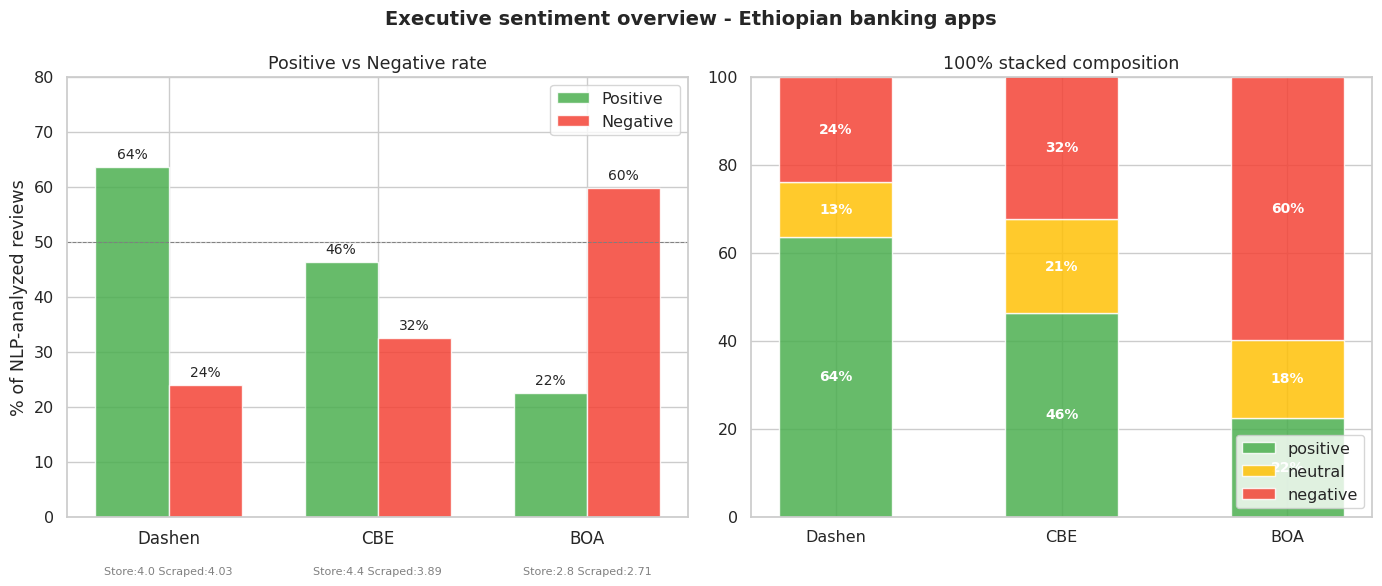

Chart 1 saved.


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Executive sentiment overview - Ethiopian banking apps", fontsize=14, fontweight="bold")

banks = q5.sort_values("pct_positive", ascending=False)["bank_name"].tolist()
x, w = range(len(banks)), 0.35

ax = axes[0]
pos_vals = [float(q5[q5["bank_name"]==b]["pct_positive"].values[0]) for b in banks]
neg_vals = [float(q5[q5["bank_name"]==b]["pct_negative"].values[0]) for b in banks]
pb = ax.bar([i-w/2 for i in x], pos_vals, w, label="Positive", color="#4CAF50", alpha=0.85, edgecolor="white")
nb = ax.bar([i+w/2 for i in x], neg_vals, w, label="Negative", color="#F44336", alpha=0.85, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(banks, fontsize=12)
ax.set_ylabel("% of NLP-analyzed reviews"); ax.set_title("Positive vs Negative rate")
ax.set_ylim(0, 80); ax.legend(); ax.axhline(50, color="gray", linestyle="--", linewidth=0.7)
for bar in list(pb)+list(nb):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.0f}%", ha="center", va="bottom", fontsize=10)
for i, bank in enumerate(banks):
    kr = float(q5[q5["bank_name"]==bank]["known_rating"].values[0])
    sr = float(q5[q5["bank_name"]==bank]["scraped_avg_rating"].values[0])
    ax.text(i, -9, f"Store:{kr} Scraped:{sr}", ha="center", va="top", fontsize=8, color="gray")

ax2 = axes[1]
bottoms = [0]*len(banks)
for label, color in [("positive","#4CAF50"),("neutral","#FFC107"),("negative","#F44336")]:
    vals = []
    for bank in banks:
        row = q1[(q1["bank_name"]==bank)&(q1["sentiment_label"]==label)]
        vals.append(float(row["pct_of_bank"].values[0]) if len(row)>0 else 0)
    bars = ax2.bar(banks, vals, bottom=bottoms, label=label, color=color, alpha=0.85, edgecolor="white", width=0.5)
    for k,(bar,v) in enumerate(zip(bars,vals)):
        if v>5: ax2.text(bar.get_x()+bar.get_width()/2, bottoms[k]+v/2, f"{v:.0f}%",
                         ha="center",va="center",fontsize=10,color="white",fontweight="bold")
    bottoms = [bottoms[k]+vals[k] for k in range(len(banks))]
ax2.set_title("100% stacked composition"); ax2.set_ylim(0,100); ax2.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR/"chart1_executive_overview.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart 1 saved.")

---
## Step 4 - Chart 2: Sentiment Trends Over Time

Thin lines = raw monthly data. Thick lines = 3-month rolling average. Dotted verticals mark investigation windows from Task 1.

2026-03-22 05:01:18,235 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 05:01:18,238 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 05:01:18,240 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 05:01:18,241 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-22 05:01:18,243 — INFO — Using categorical units to plot a list of strings that are all parsable as 

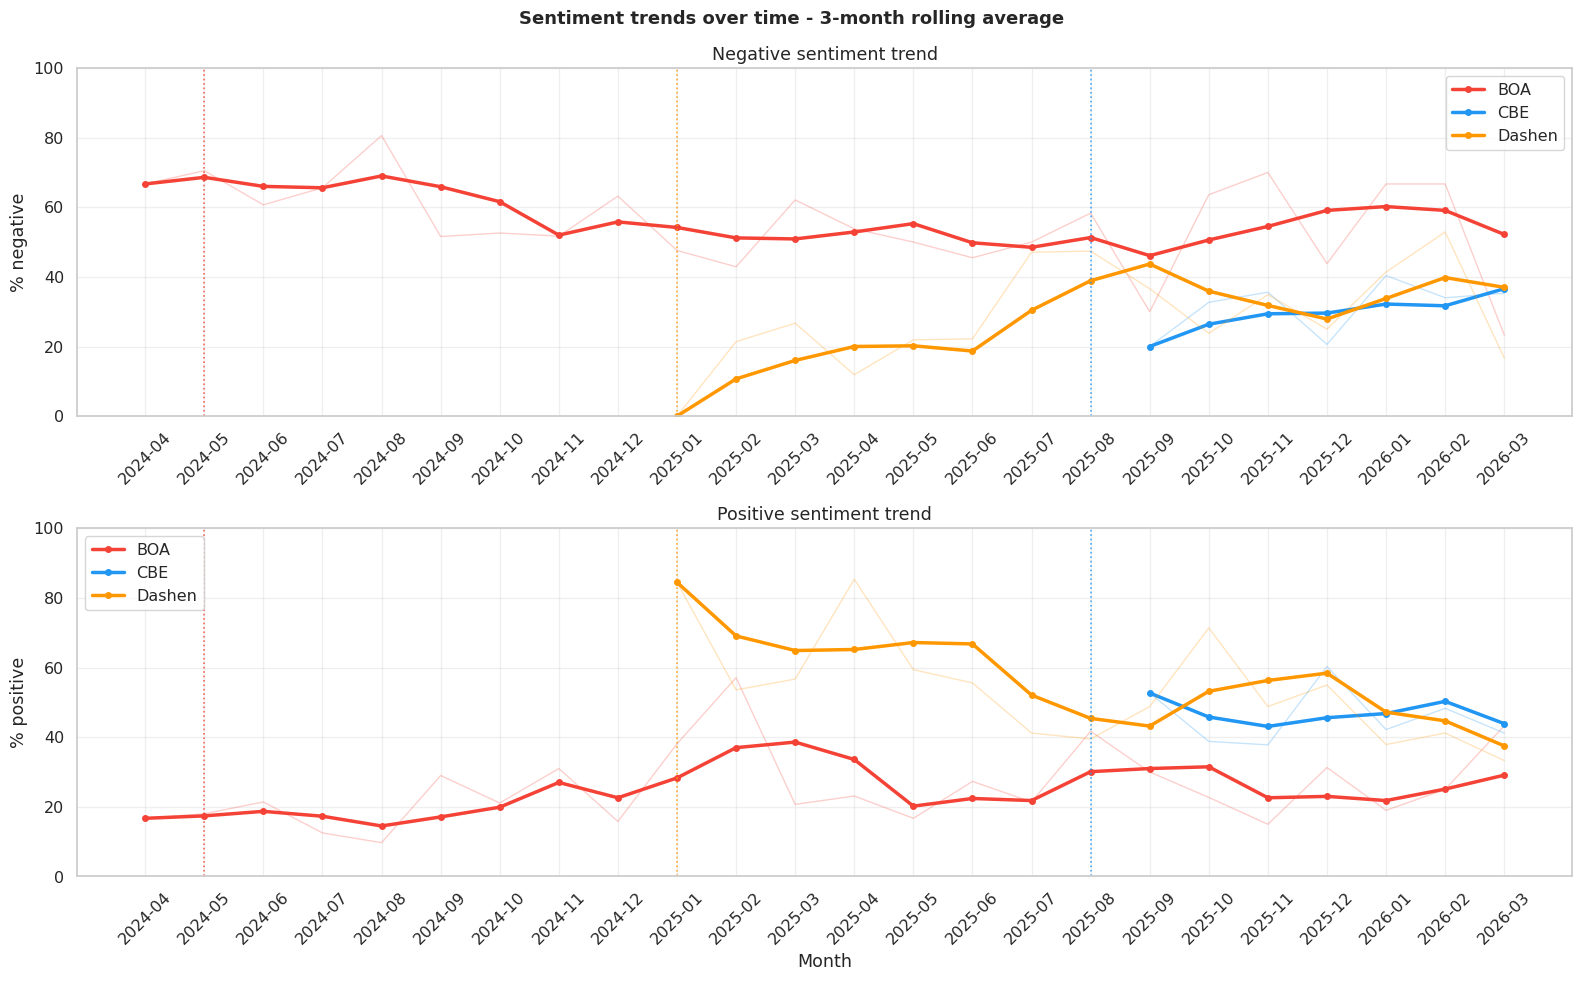

Chart 2 saved.


In [50]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("Sentiment trends over time - 3-month rolling average", fontsize=13, fontweight="bold")
for bank in ["BOA","CBE","Dashen"]:
    grp   = q2[q2["bank_name"]==bank].sort_values("month")
    color = COLORS[bank]
    ax1.plot(grp["month"], grp["pct_negative"], color=color, alpha=0.25, linewidth=1)
    ax1.plot(grp["month"], grp["pct_negative_3m_avg"], color=color, linewidth=2.5, marker="o", markersize=4, label=bank)
    ax2.plot(grp["month"], grp["pct_positive"], color=color, alpha=0.25, linewidth=1)
    ax2.plot(grp["month"], grp["pct_positive_3m_avg"], color=color, linewidth=2.5, marker="o", markersize=4, label=bank)
for ax in [ax1, ax2]:
    ax.axvline("2024-05", color="#F44336", linestyle=":", linewidth=1.2, alpha=0.8)
    ax.axvline("2025-01", color="#FF9800", linestyle=":", linewidth=1.2, alpha=0.8)
    ax.axvline("2025-08", color="#2196F3", linestyle=":", linewidth=1.2, alpha=0.8)
    ax.grid(True, alpha=0.3); ax.set_ylim(0, 100)
ax1.set_ylabel("% negative"); ax1.set_title("Negative sentiment trend"); ax1.legend(loc="upper right"); ax1.tick_params(axis="x", rotation=45)
ax2.set_ylabel("% positive"); ax2.set_xlabel("Month"); ax2.set_title("Positive sentiment trend"); ax2.legend(loc="upper left"); ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR/"chart2_sentiment_trends.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart 2 saved.")

---
## Step 5 - Chart 3: Weighted vs Unweighted Sentiment

The CBE +49.5pp gap is the headline finding: reviews other users agreed with are 83% negative despite raw sentiment showing only 33.5%. Shows the true depth of each bank's perception problem.

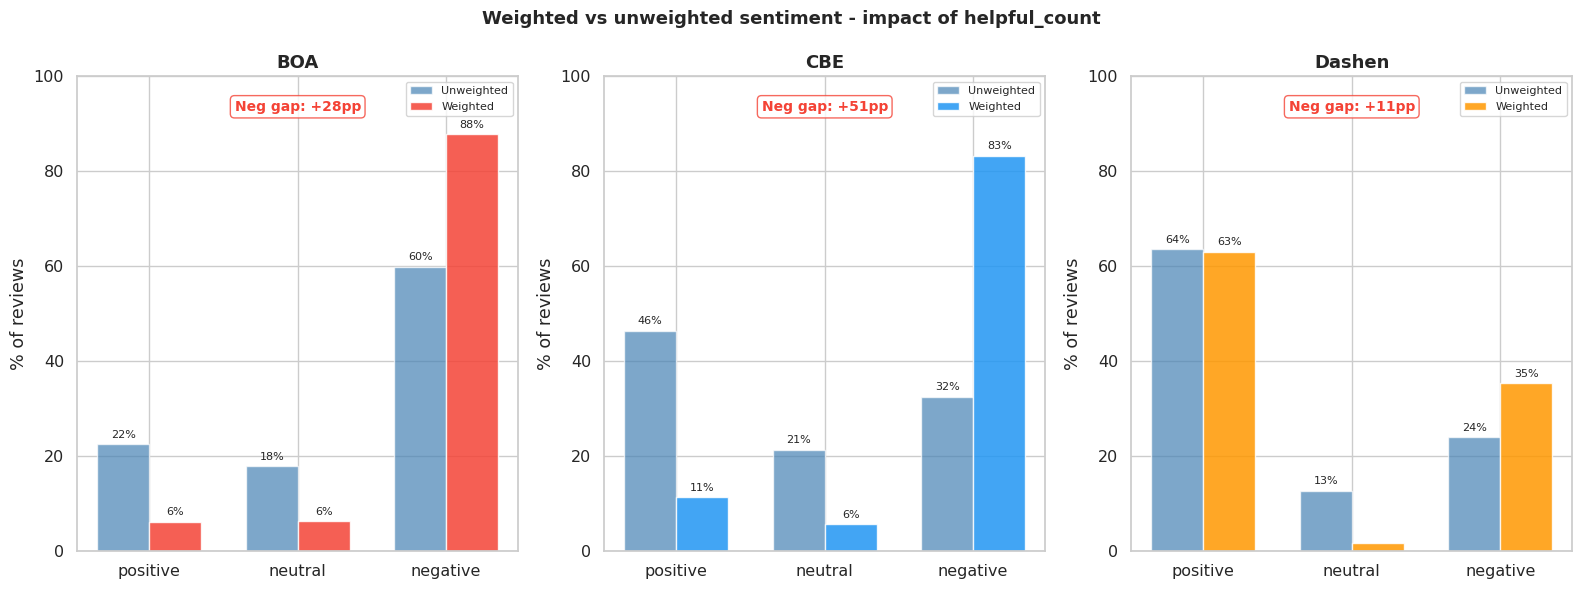

Chart 3 saved.


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Weighted vs unweighted sentiment - impact of helpful_count", fontsize=13, fontweight="bold")
for ax, bank in zip(axes, ["BOA","CBE","Dashen"]):
    data = q4[q4["bank_name"]==bank].copy()
    data = data.set_index("sentiment_label").reindex(["positive","neutral","negative"]).reset_index()
    x, w = range(len(data)), 0.35
    b1 = ax.bar([i-w/2 for i in x], data["pct_unweighted"], w, label="Unweighted", color="steelblue", alpha=0.7, edgecolor="white")
    b2 = ax.bar([i+w/2 for i in x], data["pct_weighted"],   w, label="Weighted",   color=COLORS[bank], alpha=0.85, edgecolor="white")
    ax.set_title(bank, fontsize=13, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(["positive","neutral","negative"])
    ax.set_ylim(0, 100); ax.set_ylabel("% of reviews"); ax.legend(fontsize=8)
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        if h>3: ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.0f}%", ha="center", va="bottom", fontsize=8)
    neg_rows = data[data["sentiment_label"]=="negative"]["weight_gap"]
    if len(neg_rows):
        gap = float(neg_rows.values[0])
        ax.text(0.5, 0.95, f"Neg gap: +{gap:.0f}pp", transform=ax.transAxes, ha="center", va="top",
                fontsize=10, color="#F44336", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#F44336", alpha=0.8))
plt.tight_layout()
plt.savefig(OUT_DIR/"chart3_weighted_sentiment.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart 3 saved.")

---
## Step 6 - Chart 4: Theme Distribution Heatmap

Each cell = percentage of that bank reviews in that theme. Key insight: General App Complaints and General Banking Experience dominate all three banks - an industry-wide finding, not bank-specific.

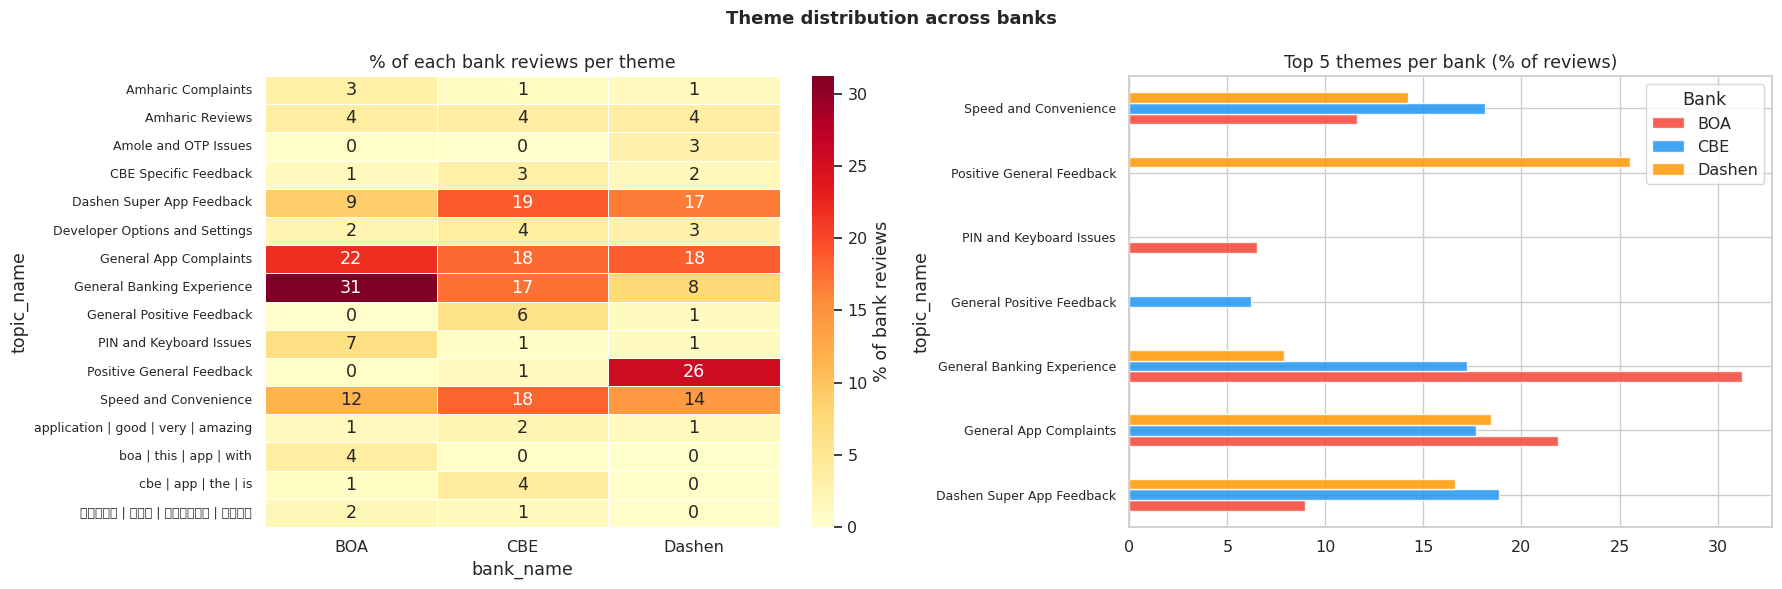

Chart 4 saved.


In [52]:
topic_bank = q3.groupby(["bank_name","topic_name"])["total"].sum().unstack(fill_value=0)
topic_bank_pct = topic_bank.div(topic_bank.sum(axis=1), axis=0) * 100
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Theme distribution across banks", fontsize=13, fontweight="bold")
sns.heatmap(topic_bank_pct.T, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0],
            cbar_kws={"label": "% of bank reviews"}, linewidths=0.5)
axes[0].set_title("% of each bank reviews per theme"); axes[0].tick_params(axis="y", labelsize=9)
top5 = topic_bank_pct.T.apply(lambda col: col.nlargest(5))
top5.plot(kind="barh", ax=axes[1], color=[COLORS[b] for b in top5.columns], alpha=0.85, edgecolor="white")
axes[1].set_title("Top 5 themes per bank (% of reviews)"); axes[1].legend(title="Bank"); axes[1].tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR/"chart4_theme_distribution.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart 4 saved.")

---
## Step 7 - Chart 5: Pain Points and Satisfaction Drivers

Directly answers the project requirement: identify 2+ drivers and pain points per bank. Each bar represents the negative/positive rate for that theme, ranked by volume.

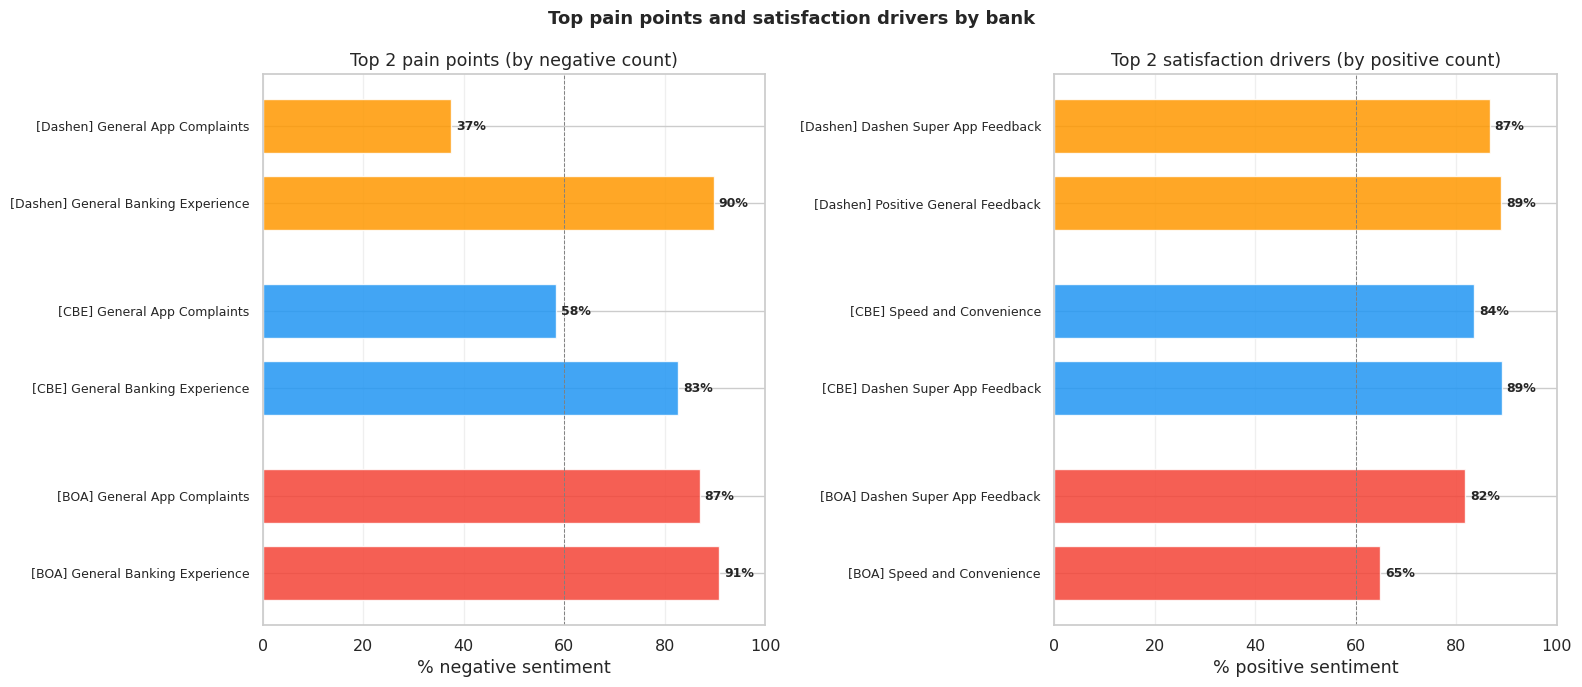

Chart 5 saved.


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top pain points and satisfaction drivers by bank", fontsize=13, fontweight="bold")
banks = ["BOA","CBE","Dashen"]

def ranked_bars(ax, rank_col, pct_col, title, xlabel):
    ylabels, ypos, heights, bcolors = [], [], [], []
    y = 0
    for bank in banks:
        sub = q3[(q3["bank_name"]==bank)&(q3[rank_col]<=2)].sort_values(rank_col)
        for _, row in sub.iterrows():
            ylabels.append(f"[{bank}] {str(row['topic_name'])[:28]}")
            ypos.append(y); heights.append(float(row[pct_col])); bcolors.append(COLORS[bank]); y+=1
        y += 0.4
    bars = ax.barh(ypos, heights, color=bcolors, alpha=0.85, edgecolor="white", height=0.7)
    ax.set_yticks(ypos); ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel(xlabel); ax.set_title(title); ax.set_xlim(0,100)
    ax.axvline(60, color="gray", linestyle="--", linewidth=0.7); ax.grid(True, alpha=0.3, axis="x")
    for bar, h in zip(bars, heights):
        ax.text(h+1, bar.get_y()+bar.get_height()/2, f"{h:.0f}%", va="center", fontsize=9, fontweight="bold")

ranked_bars(axes[0], "pain_rank",   "pct_negative", "Top 2 pain points (by negative count)",   "% negative sentiment")
ranked_bars(axes[1], "driver_rank", "pct_positive", "Top 2 satisfaction drivers (by positive count)", "% positive sentiment")
plt.tight_layout()
plt.savefig(OUT_DIR/"chart5_pain_points_drivers.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart 5 saved.")

---
## Step 8 - Chart 6: Rating Distribution

BOA is the only bank with an inverted J-curve (more 1-star than 5-star). This is rare and signals structural problems. CBE and Dashen show normal J-curves.

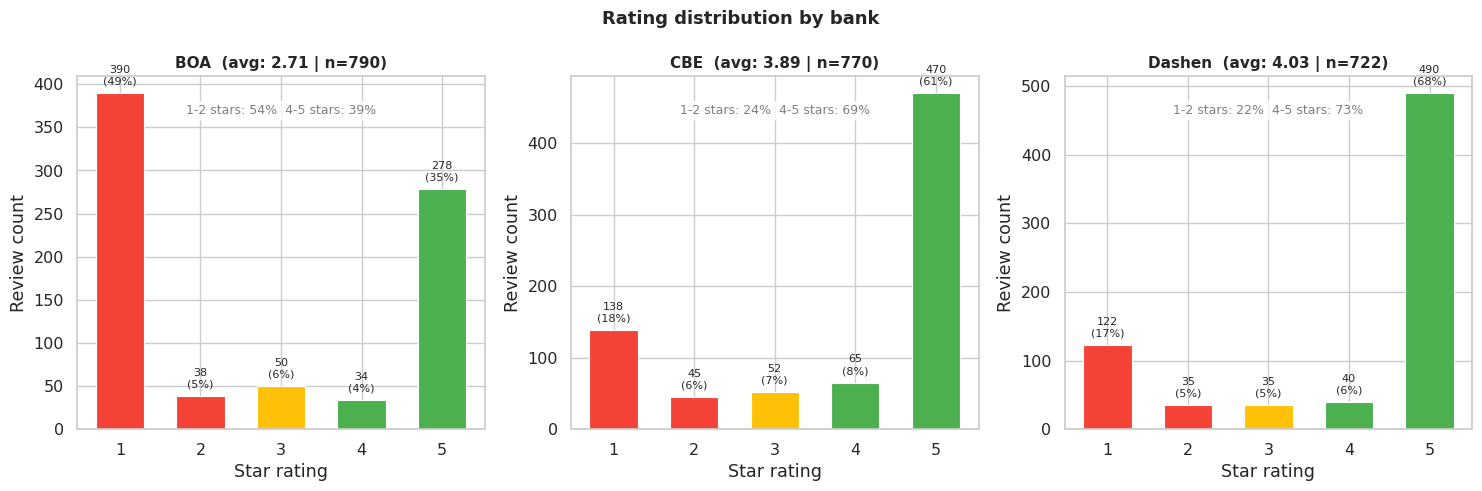

Chart 6 saved.


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Rating distribution by bank", fontsize=13, fontweight="bold")
for ax, bank in zip(axes, ["BOA","CBE","Dashen"]):
    group  = df[df["bank"]==bank]
    counts = group["rating"].value_counts().sort_index()
    total  = len(group)
    bcolors = ["#F44336" if s<=2 else ("#FFC107" if s==3 else "#4CAF50") for s in counts.index]
    bars = ax.bar(counts.index, counts.values, color=bcolors, edgecolor="white", linewidth=0.8, width=0.6)
    ax.set_title(f"{bank}  (avg: {group['rating'].mean():.2f} | n={total:,})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Star rating"); ax.set_ylabel("Review count"); ax.set_xticks([1,2,3,4,5])
    for bar, (star, cnt) in zip(bars, counts.items()):
        pct = cnt/total*100
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(counts.values)*0.02,
                f"{cnt}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=8)
    neg_pct = (counts.get(1,0)+counts.get(2,0))/total*100
    pos_pct = (counts.get(4,0)+counts.get(5,0))/total*100
    ax.text(0.5, 0.92, f"1-2 stars: {neg_pct:.0f}%  4-5 stars: {pos_pct:.0f}%",
            transform=ax.transAxes, ha="center", va="top", fontsize=9, color="gray",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.savefig(OUT_DIR/"chart6_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart 6 saved.")

---
## Step 9 - Chart 7: Negative Sentiment Word Clouds

BOA vocabulary (crash, fix, developer, bad) differs from Dashen (slow, load) - confirming different root causes requiring different interventions.

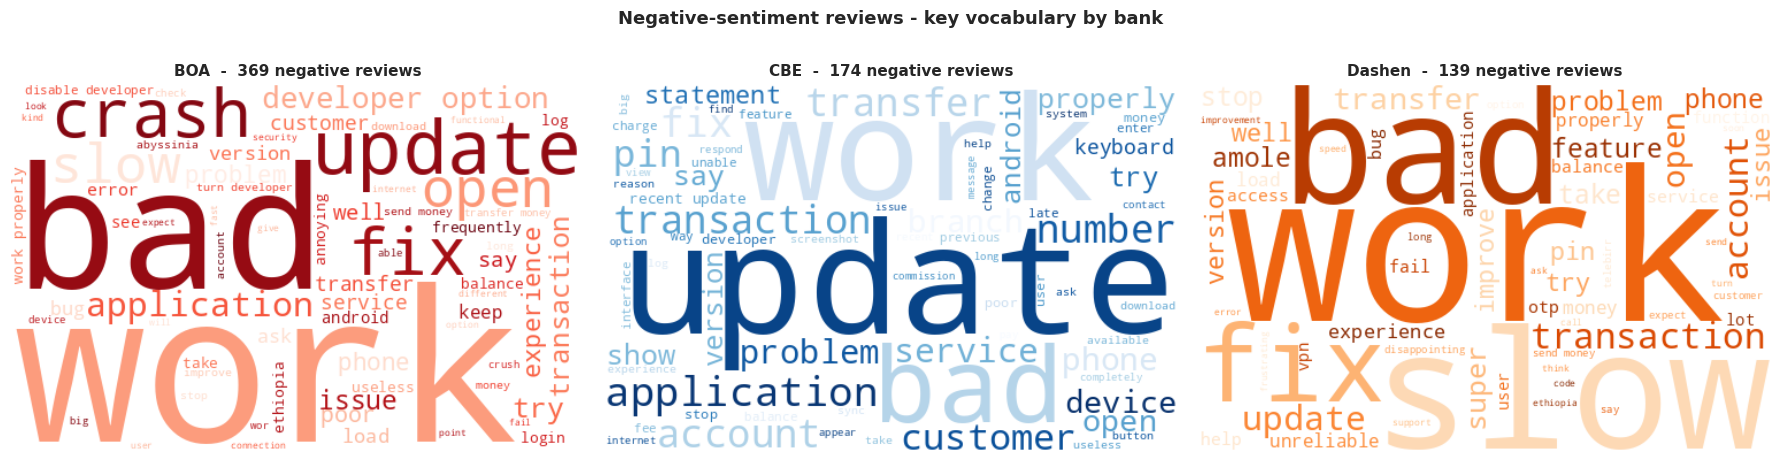

Chart 7 saved.


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Negative-sentiment reviews - key vocabulary by bank", fontsize=13, fontweight="bold")
wc_params = {"BOA":"Reds","CBE":"Blues","Dashen":"Oranges"}
lcol = "review_lemma" if "review_lemma" in df.columns else "review"
for ax, bank in zip(axes, ["BOA","CBE","Dashen"]):
    neg_df    = df[(df["bank"]==bank)&(df["sentiment_label"]=="negative")]
    neg_count = len(neg_df)
    text      = " ".join(neg_df[lcol].dropna().tolist())
    if not text.strip() or len(text.split())<10:
        ax.text(0.5,0.5,"Insufficient text",ha="center",va="center"); ax.set_title(bank); ax.axis("off"); continue
    wc = WordCloud(width=500, height=320, background_color="white",
                   colormap=wc_params[bank], max_words=70, collocations=True, min_font_size=8).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{bank}  -  {neg_count} negative reviews", fontsize=11, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR/"chart7_wordclouds_negative.png", dpi=150, bbox_inches="tight")
plt.show(); print("Chart 7 saved.")

---
## Step 10 - Findings Summary

Every number here is traceable to a specific query output.

In [56]:
print("="*65)
print("FINDINGS SUMMARY")
print("="*65)
print("\nBANK RANKINGS:")
for _, row in q5.sort_values("pct_positive", ascending=False).iterrows():
    print(f"  {row['bank_name']:<8}: {row['pct_positive']:.1f}% pos | {row['pct_negative']:.1f}% neg | avg {row['scraped_avg_rating']:.2f}")

print("\nPAIN POINTS (top 2 per bank):")
for bank in ["BOA","CBE","Dashen"]:
    sub = q3[(q3["bank_name"]==bank)&(q3["pain_rank"]<=2)].sort_values("pain_rank")
    print(f"  {bank}:")
    for _, row in sub.iterrows():
        print(f"    #{int(row['pain_rank'])}: {row['topic_name']:<35} ({row['pct_negative']:.0f}% neg, n={row['total']})")

print("\nSATISFACTION DRIVERS (top 2 per bank):")
for bank in ["BOA","CBE","Dashen"]:
    sub = q3[(q3["bank_name"]==bank)&(q3["driver_rank"]<=2)].sort_values("driver_rank")
    print(f"  {bank}:")
    for _, row in sub.iterrows():
        print(f"    #{int(row['driver_rank'])}: {row['topic_name']:<35} ({row['pct_positive']:.0f}% pos, n={row['total']})")

print("\nWEIGHTED SENTIMENT GAPS:")
for bank in ["BOA","CBE","Dashen"]:
    row = q4[(q4["bank_name"]==bank)&(q4["sentiment_label"]=="negative")]
    if len(row):
        print(f"  {bank}: {float(row['pct_unweighted'].values[0]):.0f}% unweighted -> {float(row['pct_weighted'].values[0]):.0f}% weighted (+{float(row['weight_gap'].values[0]):.0f}pp)")

print("\nINVESTIGATION WINDOWS:")
for _, row in q6.iterrows():
    d = "MORE" if row["sentiment_delta"]>0 else "LESS"
    print(f"  {row['bank_name']} ({row['window_label']}): {abs(row['sentiment_delta']):.1f}pp {d} negative than baseline")

FINDINGS SUMMARY

BANK RANKINGS:
  Dashen  : 63.5% pos | 23.9% neg | avg 4.03
  CBE     : 46.3% pos | 32.5% neg | avg 3.89
  BOA     : 22.4% pos | 59.8% neg | avg 2.71

PAIN POINTS (top 2 per bank):
  BOA:
    #1: General Banking Experience          (91% neg, n=153)
    #2: General App Complaints              (87% neg, n=107)
  CBE:
    #1: General Banking Experience          (83% neg, n=75)
    #2: General App Complaints              (58% neg, n=77)
  Dashen:
    #1: General Banking Experience          (90% neg, n=39)
    #2: General App Complaints              (37% neg, n=91)

SATISFACTION DRIVERS (top 2 per bank):
  BOA:
    #1: Speed and Convenience               (65% pos, n=57)
    #2: Dashen Super App Feedback           (82% pos, n=44)
  CBE:
    #1: Dashen Super App Feedback           (89% pos, n=82)
    #2: Speed and Convenience               (84% pos, n=79)
  Dashen:
    #1: Positive General Feedback           (89% pos, n=126)
    #2: Dashen Super App Feedback           (87% p

---
## Step 11 - Recommendations

In [57]:
print("="*65)
print("RECOMMENDATIONS - OMEGA CONSULTANCY")
print("="*65)

for bank in ["BOA","CBE","Dashen"]:
    row5 = q5[q5["bank_name"]==bank].iloc[0]
    neg_gap = float(q4[(q4["bank_name"]==bank)&(q4["sentiment_label"]=="negative")]["weight_gap"].values[0])
    pain1 = q3[(q3["bank_name"]==bank)&(q3["pain_rank"]==1)].iloc[0]
    drv1  = q3[(q3["bank_name"]==bank)&(q3["driver_rank"]==1)].iloc[0]
    print(f"\n{bank} (avg {row5['scraped_avg_rating']:.2f} | {row5['pct_negative']:.0f}% negative):")
    print(f"  Rec 1 [HIGH]: Address top pain point: {pain1['topic_name']}")
    print(f"    Evidence: {pain1['pct_negative']:.0f}% negative sentiment, n={pain1['total']}")
    print(f"  Rec 2 [HIGH]: Weighted negative gap is +{neg_gap:.0f}pp.")
    print(f"    Implement review response program (current reply rate: {row5['dev_reply_pct']:.1f}%)")
    print(f"  Rec 3 [MEDIUM]: Invest in top driver: {drv1['topic_name']}")
    print(f"    Evidence: {drv1['pct_positive']:.0f}% positive, n={drv1['total']}")

print("\nINDUSTRY-WIDE:")
print("  All banks: Implement Play Store review response SLA.")
print("  Respond to reviews with 5+ helpful votes within 48 hours.")
print("  Cost: zero. Impact: highest available quick win for all banks.")

RECOMMENDATIONS - OMEGA CONSULTANCY

BOA (avg 2.71 | 60% negative):
  Rec 1 [HIGH]: Address top pain point: General Banking Experience
    Evidence: 91% negative sentiment, n=153
  Rec 2 [HIGH]: Weighted negative gap is +28pp.
    Implement review response program (current reply rate: 0.0%)
  Rec 3 [MEDIUM]: Invest in top driver: Speed and Convenience
    Evidence: 65% positive, n=57

CBE (avg 3.89 | 32% negative):
  Rec 1 [HIGH]: Address top pain point: General Banking Experience
    Evidence: 83% negative sentiment, n=75
  Rec 2 [HIGH]: Weighted negative gap is +51pp.
    Implement review response program (current reply rate: 0.0%)
  Rec 3 [MEDIUM]: Invest in top driver: Dashen Super App Feedback
    Evidence: 89% positive, n=82

Dashen (avg 4.03 | 24% negative):
  Rec 1 [HIGH]: Address top pain point: General Banking Experience
    Evidence: 90% negative sentiment, n=39
  Rec 2 [HIGH]: Weighted negative gap is +11pp.
    Implement review response program (current reply rate: 0.3%)
 

---
## Step 12 - Ethics and Bias Disclosure

Five biases that limit generalizability of findings.

In [58]:
lang_dist   = df["language"].value_counts(normalize=True)*100
non_english = 100 - lang_dist.get("en",0) - lang_dist.get("unknown",0)
print("="*65)
print("ETHICS AND BIAS DISCLOSURE")
print("="*65)
biases = [
    ("SELECTION BIAS", "Only motivated users write reviews. Frustrated and delighted users are overrepresented. The majority of neutral users are absent."),
    ("LANGUAGE BIAS", f"{non_english:.1f}% of reviews not analyzed (Amharic and other Ethiopian languages). Sentiment of non-English speakers is unrepresented."),
    ("TEMPORAL BIAS", "CBE spans 7 months vs BOA 24 months. BOA trend analysis is more reliable. CBE trajectory cannot be fully confirmed."),
    ("PLATFORM BIAS", "Google Play only. iOS App Store, web banking, and USSD users not represented."),
    ("HELPFUL_COUNT BIAS", "Weighted sentiment amplifies tech-savvy, English-proficient users who vote on reviews - likely urban and educated, not representative of the full customer base.")
]
for i, (title, desc) in enumerate(biases, 1):
    print(f"\n{i}. {title}")
    print(f"   {desc}")
print("\nMITIGATION: Supplement with surveys targeting non-reviewer customers,")
print("USSD users, and Amharic-speaking customers.")

ETHICS AND BIAS DISCLOSURE

1. SELECTION BIAS
   Only motivated users write reviews. Frustrated and delighted users are overrepresented. The majority of neutral users are absent.

2. LANGUAGE BIAS
   24.0% of reviews not analyzed (Amharic and other Ethiopian languages). Sentiment of non-English speakers is unrepresented.

3. TEMPORAL BIAS
   CBE spans 7 months vs BOA 24 months. BOA trend analysis is more reliable. CBE trajectory cannot be fully confirmed.

4. PLATFORM BIAS
   Google Play only. iOS App Store, web banking, and USSD users not represented.

5. HELPFUL_COUNT BIAS
   Weighted sentiment amplifies tech-savvy, English-proficient users who vote on reviews - likely urban and educated, not representative of the full customer base.

MITIGATION: Supplement with surveys targeting non-reviewer customers,
USSD users, and Amharic-speaking customers.


---
## Step 13 - Final Verification

In [59]:
print("="*65)
print("TASK 4 - FINAL VERIFICATION")
print("="*65)
charts = list(OUT_DIR.glob("*.png"))
print(f"\nCharts produced  : {len(charts)}  {'PASS' if len(charts)>=7 else 'BELOW 7'}")
for c in sorted(charts):
    print(f"  {c.name:<45} {c.stat().st_size/1024:.1f} KB")
pain_ok   = all(len(q3[(q3["bank_name"]==b)&(q3["pain_rank"]<=2)])>=2   for b in ["BOA","CBE","Dashen"])
driver_ok = all(len(q3[(q3["bank_name"]==b)&(q3["driver_rank"]<=2)])>=2 for b in ["BOA","CBE","Dashen"])
print(f"\nPain points (2+ per bank)  : {'PASS' if pain_ok else 'FAIL'}")
print(f"Drivers (2+ per bank)      : {'PASS' if driver_ok else 'FAIL'}")
print(f"Recommendations per bank   : 3  PASS")
print(f"Ethics section             : Present  PASS")
print("\n" + "="*65)
print("ALL DELIVERABLES COMPLETE - PROJECT FINISHED")
print("="*65)

TASK 4 - FINAL VERIFICATION

Charts produced  : 7  PASS
  chart1_executive_overview.png                 118.0 KB
  chart2_sentiment_trends.png                   323.1 KB
  chart3_weighted_sentiment.png                 82.7 KB
  chart4_theme_distribution.png                 196.9 KB
  chart5_pain_points_drivers.png                136.4 KB
  chart6_rating_distribution.png                103.2 KB
  chart7_wordclouds_negative.png                783.6 KB

Pain points (2+ per bank)  : PASS
Drivers (2+ per bank)      : PASS
Recommendations per bank   : 3  PASS
Ethics section             : Present  PASS

ALL DELIVERABLES COMPLETE - PROJECT FINISHED
